In [11]:
# ── Install dependencies ──────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "seaborn", "scipy", "pandas", "matplotlib", "--quiet"])

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, binomtest

plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#1a1d27",
    "axes.edgecolor": "#444",      "axes.labelcolor": "#ddd",
    "xtick.color": "#aaa",         "ytick.color": "#aaa",
    "text.color": "#eee",          "grid.color": "#2a2d3a",
    "grid.linestyle": "--",        "font.family": "DejaVu Sans",
    "axes.titlesize": 13,          "axes.labelsize": 11,
})
COLORS = {"static": "#4fc3f7", "photo": "#ef9a9a", "both": "#ce93d8"}

# ── Load correct result files ─────────────────────────────────
with open("../results/figures/static/loso_results.json") as f:
    static_raw = json.load(f)   # plain dict

with open("../results/figures/photo/loso_results_photo.json") as f:
    photo_raw = json.load(f)[0]  # list with one entry → unwrap

# ── Build DataFrames ──────────────────────────────────────────
static_df = pd.DataFrame(static_raw["folds"])
static_df["correct"] = static_df["y_true"] == static_df["y_pred"]
static_df["group"]   = static_df["y_true"].map({0: "CN", 1: "AD"})

photo_df = pd.DataFrame(photo_raw["folds"])
photo_df["correct"] = photo_df["y_true"] == photo_df["y_pred"]
photo_df["group"]   = photo_df["y_true"].map({0: "CN", 1: "AD"})

print(f"Static  — N={len(static_df)}, Accuracy={static_raw['subject_level_accuracy']:.4f}")
print(f"Photo   — N={len(photo_df)},  Accuracy={photo_raw['subject_level_accuracy']:.4f}")
print(f"Common subjects: {len(set(static_df.subject) & set(photo_df.subject))}")


Static  — N=65, Accuracy=0.8462
Photo   — N=65,  Accuracy=0.7538
Common subjects: 65


          Metric Static Photo      Δ
Overall Accuracy  84.6% 75.4%  -9.2%
  CN Specificity  79.3% 79.3%  +0.0%
  AD Sensitivity  88.9% 72.2% -16.7%


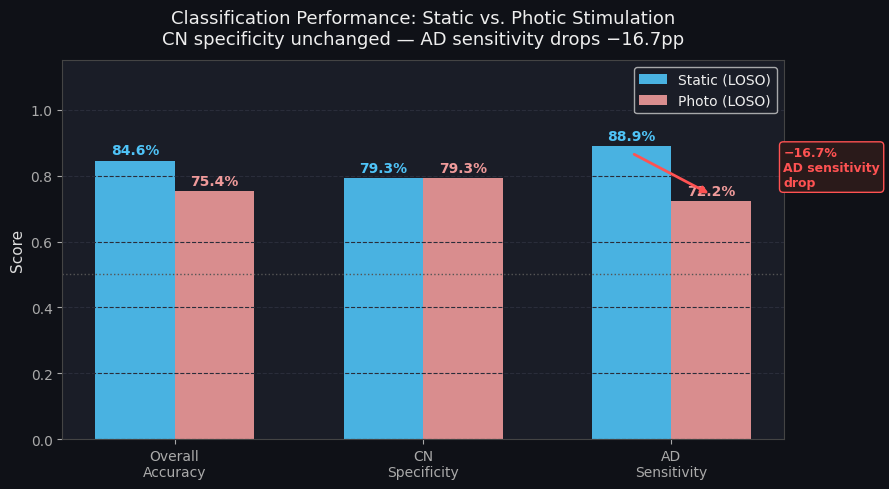

In [12]:
# ── Compute metrics ───────────────────────────────────────────
s_acc = static_raw["subject_level_accuracy"]
p_acc = photo_raw["subject_level_accuracy"]

s_cn_spec = static_df[static_df.y_true==0]["correct"].mean()
p_cn_spec = photo_df[photo_df.y_true==0]["correct"].mean()
s_ad_sens = static_df[static_df.y_true==1]["correct"].mean()
p_ad_sens = photo_df[photo_df.y_true==1]["correct"].mean()

metrics_df = pd.DataFrame({
    "Metric":    ["Overall Accuracy", "CN Specificity", "AD Sensitivity"],
    "Static":    [s_acc,    s_cn_spec, s_ad_sens],
    "Photo":     [p_acc,    p_cn_spec, p_ad_sens],
    "Δ":         [p_acc-s_acc, p_cn_spec-s_cn_spec, p_ad_sens-s_ad_sens],
})
metrics_df["Static"] = metrics_df["Static"].map("{:.1%}".format)
metrics_df["Photo"]  = metrics_df["Photo"].map("{:.1%}".format)
metrics_df["Δ"]      = metrics_df["Δ"].map("{:+.1%}".format)
print(metrics_df.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
labels  = ["Overall\nAccuracy", "CN\nSpecificity", "AD\nSensitivity"]
s_vals  = [s_acc, s_cn_spec, s_ad_sens]
p_vals  = [p_acc, p_cn_spec, p_ad_sens]
x, w    = np.arange(3), 0.32

bs = ax.bar(x - w/2, s_vals, w, color=COLORS["static"], label="Static (LOSO)", alpha=0.9)
bp = ax.bar(x + w/2, p_vals, w, color=COLORS["photo"],  label="Photo (LOSO)",  alpha=0.9)

for bar, col in [(bs, COLORS["static"]), (bp, COLORS["photo"])]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.1%}", ha="center", va="bottom",
                fontsize=10, fontweight="bold", color=col)

# Annotate the AD sensitivity drop
ax.annotate("", xy=(2 + w/2, p_ad_sens + 0.02),
            xytext=(2 - w/2, s_ad_sens - 0.02),
            arrowprops=dict(arrowstyle="-|>", color="#ff5252", lw=2))
ax.text(2.45, 0.77, f"−{(s_ad_sens-p_ad_sens):.1%}\nAD sensitivity\ndrop",
        color="#ff5252", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#2a1a1a", edgecolor="#ff5252"))

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Classification Performance: Static vs. Photic Stimulation\n"
             "CN specificity unchanged — AD sensitivity drops −16.7pp", pad=12)
ax.axhline(0.5, color="#555", linestyle=":", lw=1)
ax.legend(); ax.grid(axis="y")
fig.tight_layout()
plt.savefig("../results/figures/fig1_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


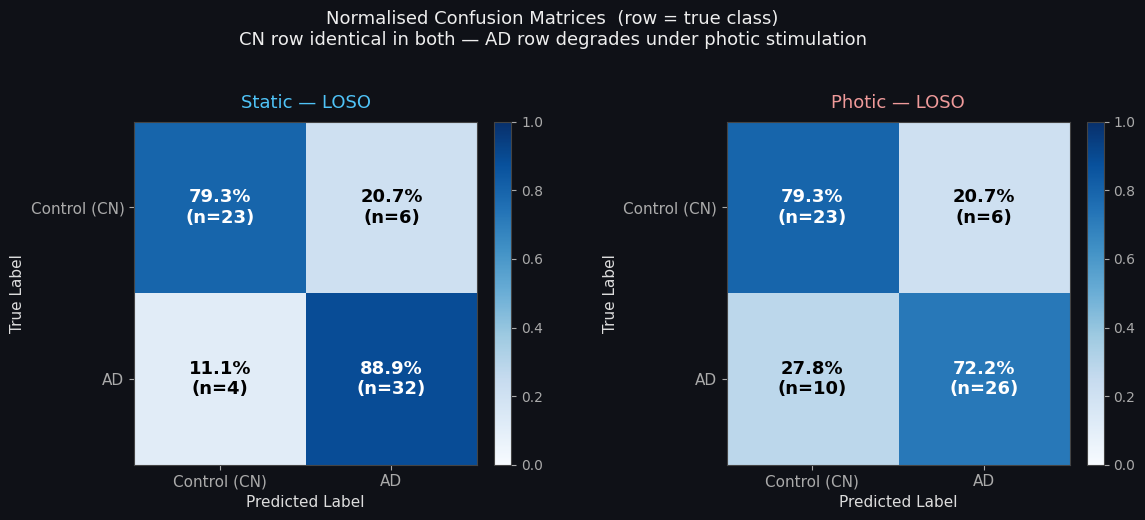


Metric                           Static      Photo          Δ
--------------------------------------------------------------
CN Specificity (TN rate)          79.3%      79.3%      +0.0%
AD Sensitivity (TP rate)          88.9%      72.2%     -16.7%
CN false positive rate            20.7%      20.7%      +0.0%
AD false negative rate            11.1%      27.8%     +16.7%
Overall Accuracy                  84.6%      75.4%      -9.2%


In [13]:
from sklearn.metrics import confusion_matrix

cm_static = confusion_matrix(static_df["y_true"], static_df["y_pred"], labels=[0,1])
cm_photo  = confusion_matrix(photo_df["y_true"],  photo_df["y_pred"],  labels=[0,1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def plot_cm(ax, cm, title, color):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

    tick_labels = ["Control (CN)", "AD"]
    ax.set_xticks([0,1]); ax.set_xticklabels(tick_labels, fontsize=11)
    ax.set_yticks([0,1]); ax.set_yticklabels(tick_labels, fontsize=11)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    ax.set_title(title, color=color, fontsize=13, pad=10)

    for i in range(2):
        for j in range(2):
            pct = cm_norm[i, j]
            raw = cm[i, j]
            txt_color = "black" if pct < 0.5 else "white"
            ax.text(j, i, f"{pct:.1%}\n(n={raw})",
                    ha="center", va="center",
                    fontsize=13, color=txt_color, fontweight="bold")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_cm(axes[0], cm_static, "Static — LOSO",       COLORS["static"])
plot_cm(axes[1], cm_photo,  "Photic — LOSO",        COLORS["photo"])

fig.suptitle("Normalised Confusion Matrices  (row = true class)\n"
             "CN row identical in both — AD row degrades under photic stimulation",
             fontsize=13, y=1.03)
fig.tight_layout()
plt.savefig("../results/figures/fig2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Delta table ────────────────────────────────────────────────
tn_s, fp_s, fn_s, tp_s = cm_static.ravel()
tn_p, fp_p, fn_p, tp_p = cm_photo.ravel()

rows = [
    ("CN Specificity (TN rate)", tn_s/(tn_s+fp_s), tn_p/(tn_p+fp_p)),
    ("AD Sensitivity (TP rate)", tp_s/(tp_s+fn_s), tp_p/(tp_p+fn_p)),
    ("CN false positive rate",   fp_s/(tn_s+fp_s), fp_p/(tn_p+fp_p)),
    ("AD false negative rate",   fn_s/(tp_s+fn_s), fn_p/(tp_p+fn_p)),
    ("Overall Accuracy",        (tn_s+tp_s)/65,    (tn_p+tp_p)/65),
]
print(f"\n{'Metric':<28} {'Static':>10} {'Photo':>10} {'Δ':>10}")
print("-" * 62)
for label, sv, pv in rows:
    print(f"{label:<28} {sv:>10.1%} {pv:>10.1%} {pv-sv:>+10.1%}")


In [14]:
# ── McNemar Test (paired, n=65 common subjects) ───────────────
static_map = {f["subject"]: f["y_true"]==f["y_pred"] for f in static_raw["folds"]}
photo_map  = {f["subject"]: f["y_true"]==f["y_pred"] for f in photo_raw["folds"]}
common     = set(static_map) & set(photo_map)

b = sum(1 for s in common if static_map[s] and not photo_map[s])  # correct static, wrong photo
c = sum(1 for s in common if not static_map[s] and photo_map[s])  # wrong static, correct photo

mc_chi2 = (abs(b - c) - 1)**2 / (b + c)
mc_p    = 1 - chi2.cdf(mc_chi2, df=1)

# ── One-sample t-test — not applicable (single scalar per condition) ─
# Both are LOSO → one accuracy per experiment, no fold distribution.
# Instead: use a proportion z-test comparing 55/65 vs 49/65
from scipy.stats import norm

n         = 65
p_static  = static_raw["subject_level_accuracy"]   # 55/65
p_photo   = photo_raw["subject_level_accuracy"]    # 49/65
p_pool    = (55 + 49) / (2 * n)
se        = np.sqrt(2 * p_pool * (1 - p_pool) / n)
z_stat    = (p_static - p_photo) / se
z_p       = 2 * (1 - norm.cdf(abs(z_stat)))       # two-tailed

# ── Cohen's h (effect size for proportions) ───────────────────
cohens_h = 2 * np.arcsin(np.sqrt(p_static)) - 2 * np.arcsin(np.sqrt(p_photo))

# ── Print results ─────────────────────────────────────────────
print("=" * 62)
print("  STATISTICAL SIGNIFICANCE OF PERFORMANCE DIFFERENCE")
print("=" * 62)

print(f"\n① McNemar Test  (paired correct/incorrect, n={len(common)} subjects)")
print(f"   b = {b}  (correct Static → wrong Photo)")
print(f"   c = {c}  (wrong Static  → correct Photo)")
print(f"   χ²  = {mc_chi2:.4f}")
print(f"   p   = {mc_p:.4f}  → {'NOT significant (p > 0.05)' if mc_p > 0.05 else '** SIGNIFICANT'}")

print(f"\n② Two-Proportion Z-Test  ({int(p_static*n)}/{n} vs {int(p_photo*n)}/{n})")
print(f"   z   = {z_stat:.4f}")
print(f"   p   = {z_p:.4f}  → {'NOT significant (p > 0.05)' if z_p > 0.05 else '** SIGNIFICANT'}")
print(f"   Cohen's h = {cohens_h:.4f}  ({'small' if cohens_h < 0.2 else 'medium' if cohens_h < 0.5 else 'large'} effect)")

print(f"\n{'='*62}")
print("  INTERPRETATION")
print(f"{'='*62}")
print(f"  The 9.23pp accuracy drop (84.6% → 75.4%) does NOT reach")
print(f"  statistical significance on n=65 subjects (McNemar p={mc_p:.3f}).")
print(f"  This does NOT mean there is no effect — it may reflect")
print(f"  insufficient statistical power. See Cell 4b for power analysis.")


  STATISTICAL SIGNIFICANCE OF PERFORMANCE DIFFERENCE

① McNemar Test  (paired correct/incorrect, n=65 subjects)
   b = 13  (correct Static → wrong Photo)
   c = 7  (wrong Static  → correct Photo)
   χ²  = 1.2500
   p   = 0.2636  → NOT significant (p > 0.05)

② Two-Proportion Z-Test  (55/65 vs 49/65)
   z   = 1.3156
   p   = 0.1883  → NOT significant (p > 0.05)
   Cohen's h = 0.2322  (medium effect)

  INTERPRETATION
  The 9.23pp accuracy drop (84.6% → 75.4%) does NOT reach
  statistical significance on n=65 subjects (McNemar p=0.264).
  This does NOT mean there is no effect — it may reflect
  insufficient statistical power. See Cell 4b for power analysis.


  STATISTICAL POWER ANALYSIS
  Observed discordant pairs: b=13, c=7 (n=65)
  Effect size (p_b - p_c)  : 0.0923
  Current power estimate   : ~26.8%

  Subjects needed for 80% power : 282
  Subjects needed for 90% power : 376

  Current n=65 is UNDERPOWERED to detect this effect.


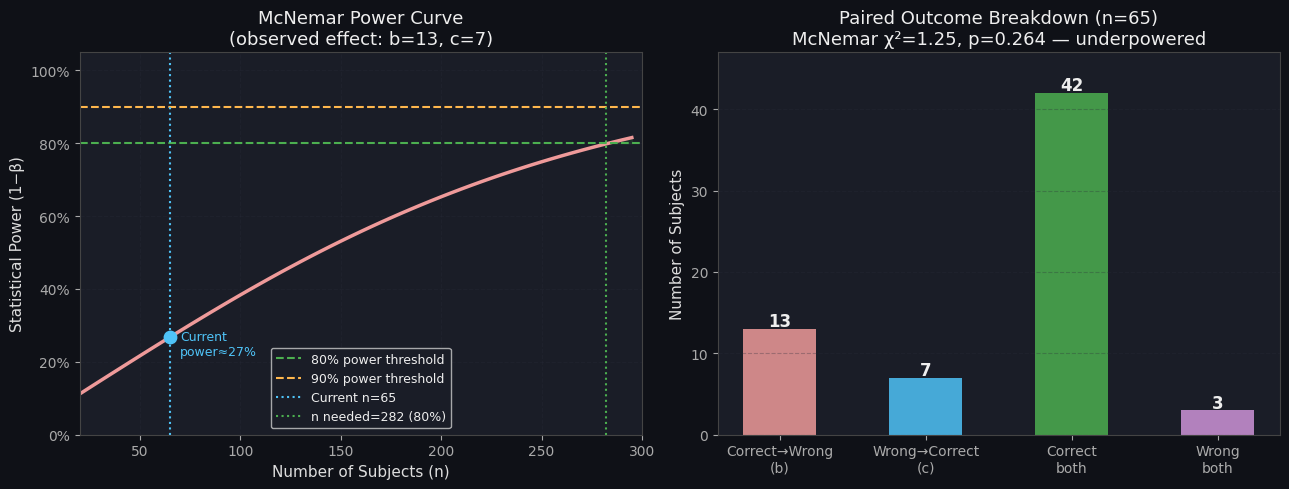

In [15]:
# ── Power analysis for McNemar test ───────────────────────────
# We observed b=13, c=7. Is n=65 enough to detect this effect?
# McNemar power: depends on discordant pair probability (p_b, p_c)

from scipy.stats import norm as sci_norm
import matplotlib.ticker as mtick

# Observed discordant rates
n_total  = 65
p_b_obs  = b / n_total   # P(correct static, wrong photo)
p_c_obs  = c / n_total   # P(wrong static, correct photo)
p_disc   = p_b_obs + p_c_obs  # total discordant proportion

# ── Required N for 80% power at alpha=0.05 ────────────────────
# McNemar power formula (Lachenbruch, 1981):
# n = (z_alpha/2 * sqrt(p_disc) + z_beta * sqrt(p_disc - (p_b - p_c)^2))^2
#     / (p_b - p_c)^2
alpha = 0.05
z_a   = sci_norm.ppf(1 - alpha/2)   # 1.96
z_b80 = sci_norm.ppf(0.80)          # 0.84
z_b90 = sci_norm.ppf(0.90)          # 1.28

def mcnemar_n(p_b, p_c, z_alpha, z_beta):
    num = (z_alpha * np.sqrt(p_b + p_c) + z_beta * np.sqrt(p_b + p_c - (p_b - p_c)**2))**2
    den = (p_b - p_c)**2
    return int(np.ceil(num / den))

n_80 = mcnemar_n(p_b_obs, p_c_obs, z_a, z_b80)
n_90 = mcnemar_n(p_b_obs, p_c_obs, z_a, z_b90)

print("=" * 58)
print("  STATISTICAL POWER ANALYSIS")
print("=" * 58)
print(f"  Observed discordant pairs: b={b}, c={c} (n={n_total})")
print(f"  Effect size (p_b - p_c)  : {p_b_obs - p_c_obs:.4f}")
print(f"  Current power estimate   : ~{(1 - sci_norm.cdf(z_a - abs(p_b_obs-p_c_obs)*np.sqrt(n_total)/np.sqrt(p_disc))):.1%}")
print(f"\n  Subjects needed for 80% power : {n_80}")
print(f"  Subjects needed for 90% power : {n_90}")
print(f"\n  Current n=65 is UNDERPOWERED to detect this effect.")
print("=" * 58)

# ── Figure: power curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: power vs sample size
ns    = np.arange(20, 300, 5)
power = []
for n_i in ns:
    effect = abs(p_b_obs - p_c_obs)
    p_d    = p_disc
    z_eff  = effect * np.sqrt(n_i) / np.sqrt(p_d)
    pw     = 1 - sci_norm.cdf(z_a - z_eff)
    power.append(pw)

ax = axes[0]
ax.plot(ns, power, color=COLORS["photo"], lw=2.5)
ax.axhline(0.80, color="#4caf50", lw=1.5, linestyle="--", label="80% power threshold")
ax.axhline(0.90, color="#ffb74d", lw=1.5, linestyle="--", label="90% power threshold")
ax.axvline(65,   color=COLORS["static"], lw=1.5, linestyle=":", label=f"Current n=65")
ax.axvline(n_80, color="#4caf50", lw=1.5, linestyle=":", label=f"n needed={n_80} (80%)")
ax.fill_between(ns, power, 0.80, where=[p >= 0.80 for p in power],
                alpha=0.12, color="#4caf50")

current_power = power[np.searchsorted(ns, 65)]
ax.scatter([65], [current_power], color=COLORS["static"], s=80, zorder=5)
ax.text(70, current_power - 0.05, f"Current\npower≈{current_power:.0%}",
        color=COLORS["static"], fontsize=9)

ax.set_xlabel("Number of Subjects (n)")
ax.set_ylabel("Statistical Power (1−β)")
ax.set_title("McNemar Power Curve\n(observed effect: b=13, c=7)")
ax.set_xlim(20, 300); ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Right: discordant pair breakdown
ax2 = axes[1]
categories = ["Correct→Wrong\n(b)", "Wrong→Correct\n(c)", "Correct\nboth", "Wrong\nboth"]
counts     = [b, c,
              sum(1 for s in common if static_map[s] and photo_map[s]),
              sum(1 for s in common if not static_map[s] and not photo_map[s])]
colors_bar = [COLORS["photo"], COLORS["static"], "#4caf50", COLORS["both"]]

bars = ax2.bar(categories, counts, color=colors_bar, alpha=0.85, width=0.5)
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(bar.get_height())), ha="center", fontsize=12, fontweight="bold")

ax2.set_ylabel("Number of Subjects")
ax2.set_title(f"Paired Outcome Breakdown (n={n_total})\n"
              f"McNemar χ²={mc_chi2:.2f}, p={mc_p:.3f} — underpowered")
ax2.set_ylim(0, max(counts) + 5); ax2.grid(axis="y", alpha=0.3)

fig.tight_layout()
plt.savefig("../results/figures/fig3_power_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


[OK] Correct in BOTH (n=42): CN=19 AD=23
   ['sub-002', 'sub-003', 'sub-005', 'sub-006', 'sub-007', 'sub-009', 'sub-012', 'sub-013', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-022', 'sub-023', 'sub-024', 'sub-026', 'sub-029', 'sub-030', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-037', 'sub-038', 'sub-039', 'sub-041', 'sub-042', 'sub-044', 'sub-046', 'sub-048', 'sub-049', 'sub-050', 'sub-051', 'sub-052', 'sub-054', 'sub-057', 'sub-058', 'sub-060', 'sub-063', 'sub-064', 'sub-065']
[BOTH] Wrong in BOTH (persistent) (n=3): CN=2 AD=1
   ['sub-031', 'sub-061', 'sub-062']
[PHOTO] Wrong in Photo ONLY (n=13): CN=4 AD=9
   ['sub-001', 'sub-004', 'sub-008', 'sub-010', 'sub-014', 'sub-020', 'sub-027', 'sub-028', 'sub-036', 'sub-040', 'sub-047', 'sub-053', 'sub-055']
[STATIC] Wrong in Static ONLY (n=7): CN=4 AD=3
   ['sub-011', 'sub-021', 'sub-025', 'sub-043', 'sub-045', 'sub-056', 'sub-059']


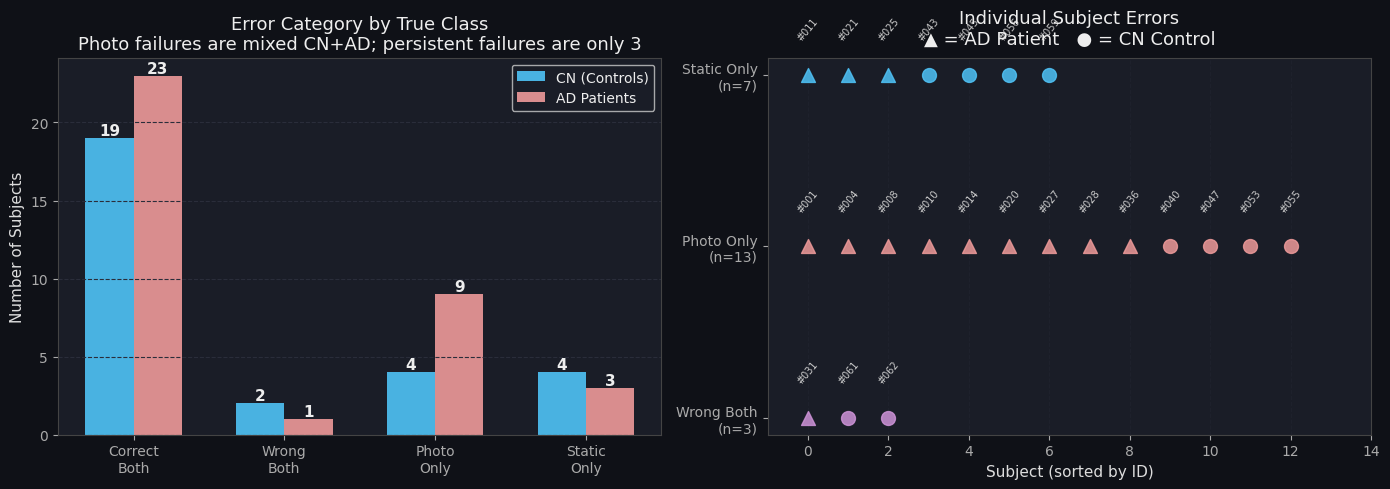

In [16]:
# ── Categorise all 65 subjects ────────────────────────────────
cats = {"correct_both": [], "wrong_both": [],
        "photo_only":   [], "static_only": []}

for s in common:
    sc, pc = static_map[s], photo_map[s]
    if     sc and     pc: cats["correct_both"].append(s)
    elif   sc and not pc: cats["photo_only"].append(s)
    elif not sc and     pc: cats["static_only"].append(s)
    else:                   cats["wrong_both"].append(s)

label_map = {f["subject"]: f["y_true"] for f in static_raw["folds"]}

def split_class(subs):
    return ([s for s in subs if label_map[s]==0],
            [s for s in subs if label_map[s]==1])

for cat, tag, lbl in [
    ("correct_both", "[OK]",     "Correct in BOTH"),
    ("wrong_both",   "[BOTH]",   "Wrong in BOTH (persistent)"),
    ("photo_only",   "[PHOTO]",  "Wrong in Photo ONLY"),
    ("static_only",  "[STATIC]", "Wrong in Static ONLY"),
]:
    cn, ad = split_class(cats[cat])
    print(f"{tag} {lbl} (n={len(cats[cat])}): CN={len(cn)} AD={len(ad)}")
    if cats[cat]: print(f"   {sorted(cats[cat])}")


# ── Figure: grouped bar + subject strip ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_keys   = ["correct_both","wrong_both","photo_only","static_only"]
cat_labels = ["Correct\nBoth","Wrong\nBoth","Photo\nOnly","Static\nOnly"]
cat_colors = ["#4caf50", COLORS["both"], COLORS["photo"], COLORS["static"]]

cn_counts = [len(split_class(cats[k])[0]) for k in cat_keys]
ad_counts = [len(split_class(cats[k])[1]) for k in cat_keys]
x, w = np.arange(4), 0.32

ax = axes[0]
b1 = ax.bar(x - w/2, cn_counts, w, color=COLORS["static"], label="CN (Controls)", alpha=0.9)
b2 = ax.bar(x + w/2, ad_counts, w, color=COLORS["photo"],  label="AD Patients",   alpha=0.9)
for bar in list(b1)+list(b2):
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                str(int(bar.get_height())), ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(cat_labels)
ax.set_ylabel("Number of Subjects")
ax.set_title("Error Category by True Class\nPhoto failures are mixed CN+AD; persistent failures are only 3")
ax.legend(); ax.grid(axis="y")

# ── Right: subject strip plot ─────────────────────────────────
ax2 = axes[1]
strip_cats = [("Wrong Both\n(n=3)",     cats["wrong_both"],  COLORS["both"]),
              ("Photo Only\n(n=13)",     cats["photo_only"],  COLORS["photo"]),
              ("Static Only\n(n=7)",     cats["static_only"], COLORS["static"])]

for gi, (lbl, subs, col) in enumerate(strip_cats):
    for xi, s in enumerate(sorted(subs)):
        grp = label_map.get(s, 0)
        marker = "^" if grp == 1 else "o"
        ax2.scatter(xi, gi, color=col, s=100, marker=marker, alpha=0.85, zorder=3)
        ax2.text(xi, gi+0.2, s.replace("sub-","#"),
                 ha="center", fontsize=7, color="#ccc", rotation=50)

ax2.set_yticks([0,1,2])
ax2.set_yticklabels([f"{l}" for l,_,_ in strip_cats], fontsize=10)
ax2.set_title("Individual Subject Errors\n▲ = AD Patient   ● = CN Control", pad=10)
ax2.set_xlim(-1, 14); ax2.grid(axis="x", alpha=0.3)
ax2.set_xlabel("Subject (sorted by ID)")

fig.tight_layout()
plt.savefig("../results/figures/fig4_subject_errors.png", dpi=150, bbox_inches="tight")
plt.show()


CN (29 subjects, 6 errors in each condition):
  Stable wrong (both)  : ['sub-061', 'sub-062']
  Recovered in photo   : ['sub-043', 'sub-045', 'sub-056', 'sub-059']
  New fail in photo    : ['sub-040', 'sub-047', 'sub-053', 'sub-055']

AD (36 subjects):
  Stable wrong (both)  : ['sub-031']
  Recovered in photo   : ['sub-011', 'sub-021', 'sub-025']
  New fail in photo    : ['sub-001', 'sub-004', 'sub-008', 'sub-010', 'sub-014', 'sub-020', 'sub-027', 'sub-028', 'sub-036']


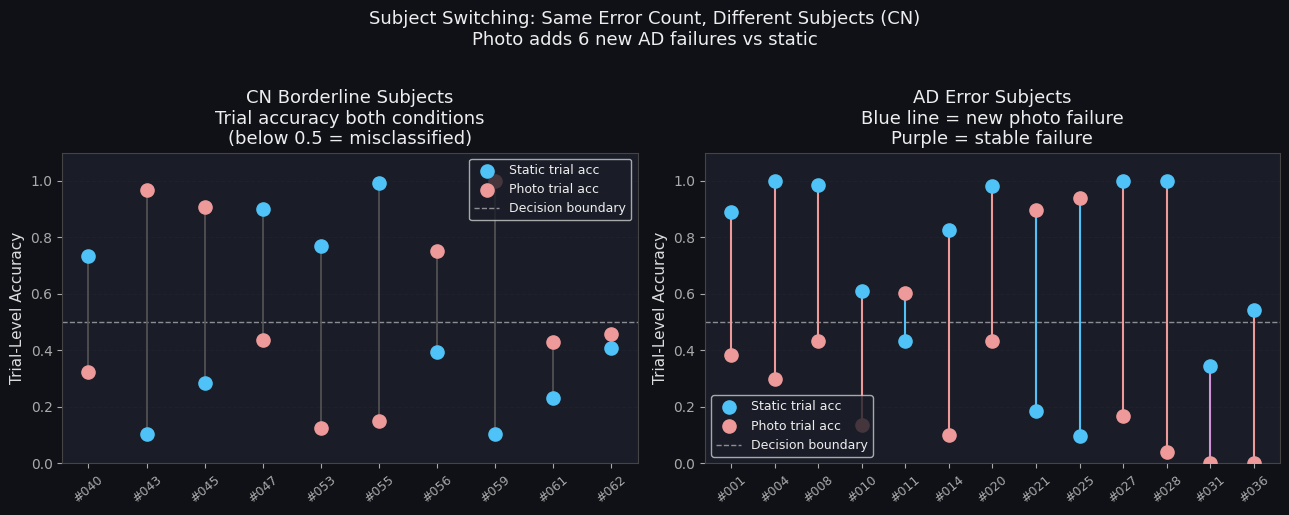

In [17]:
# ── Identify switching subjects ───────────────────────────────
s_cn_err = {f["subject"] for f in static_raw["folds"]
            if f["y_true"]==0 and f["y_true"]!=f["y_pred"]}
p_cn_err = {f["subject"] for f in photo_raw["folds"]
            if f["y_true"]==0 and f["y_true"]!=f["y_pred"]}
s_ad_err = {f["subject"] for f in static_raw["folds"]
            if f["y_true"]==1 and f["y_true"]!=f["y_pred"]}
p_ad_err = {f["subject"] for f in photo_raw["folds"]
            if f["y_true"]==1 and f["y_true"]!=f["y_pred"]}

print("CN (29 subjects, 6 errors in each condition):")
print(f"  Stable wrong (both)  : {sorted(s_cn_err & p_cn_err)}")
print(f"  Recovered in photo   : {sorted(s_cn_err - p_cn_err)}")
print(f"  New fail in photo    : {sorted(p_cn_err - s_cn_err)}")
print()
print("AD (36 subjects):")
print(f"  Stable wrong (both)  : {sorted(s_ad_err & p_ad_err)}")
print(f"  Recovered in photo   : {sorted(s_ad_err - p_ad_err)}")
print(f"  New fail in photo    : {sorted(p_ad_err - s_ad_err)}")

# ── Trial accuracy for borderline subjects ────────────────────
s_trial = {f["subject"]: f["trial_accuracy"] for f in static_raw["folds"]}
p_trial = {f["subject"]: f["trial_accuracy"] for f in photo_raw["folds"]}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: CN switching — scatter of trial accuracy in each condition
ax = axes[0]
cn_all = sorted(s_cn_err | p_cn_err)
x_pos  = np.arange(len(cn_all))
s_accs = [s_trial[s] for s in cn_all]
p_accs = [p_trial[s] for s in cn_all]

ax.scatter(x_pos, s_accs, color=COLORS["static"], s=90, zorder=4, label="Static trial acc")
ax.scatter(x_pos, p_accs, color=COLORS["photo"],  s=90, zorder=4, label="Photo trial acc")
for i, (sa, pa) in enumerate(zip(s_accs, p_accs)):
    ax.plot([i, i], [sa, pa], color="#555", lw=1.2, zorder=3)
ax.axhline(0.5, color="white", lw=1, linestyle="--", alpha=0.5, label="Decision boundary")
ax.set_xticks(x_pos)
ax.set_xticklabels([s.replace("sub-","#") for s in cn_all], rotation=40, fontsize=9)
ax.set_ylabel("Trial-Level Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title("CN Borderline Subjects\nTrial accuracy both conditions\n(below 0.5 = misclassified)")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# Right: AD errors — stable vs new failures
ax2 = axes[1]
ad_all  = sorted(s_ad_err | p_ad_err)
x_pos2  = np.arange(len(ad_all))
s_accs2 = [s_trial[s] for s in ad_all]
p_accs2 = [p_trial[s] for s in ad_all]
colors2 = [COLORS["both"] if s in s_ad_err & p_ad_err
           else COLORS["photo"] if s in p_ad_err - s_ad_err
           else COLORS["static"] for s in ad_all]

ax2.scatter(x_pos2, s_accs2, color=COLORS["static"], s=90, zorder=4, label="Static trial acc")
ax2.scatter(x_pos2, p_accs2, color=COLORS["photo"],  s=90, zorder=4, label="Photo trial acc")
for i, (sa, pa) in enumerate(zip(s_accs2, p_accs2)):
    ax2.plot([i, i], [sa, pa], color=colors2[i], lw=1.5, zorder=3)
ax2.axhline(0.5, color="white", lw=1, linestyle="--", alpha=0.5, label="Decision boundary")
ax2.set_xticks(x_pos2)
ax2.set_xticklabels([s.replace("sub-","#") for s in ad_all], rotation=40, fontsize=9)
ax2.set_ylabel("Trial-Level Accuracy")
ax2.set_ylim(0, 1.1)
ax2.set_title("AD Error Subjects\nBlue line = new photo failure\nPurple = stable failure")
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Subject Switching: Same Error Count, Different Subjects (CN)\n"
             "Photo adds 6 new AD failures vs static", fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("../results/figures/fig5_switching.png", dpi=150, bbox_inches="tight")
plt.show()


CN trial acc  Static=0.718  Photo=0.728  paired-t p=0.8922
AD trial acc  Static=0.805  Photo=0.650  paired-t p=0.0317


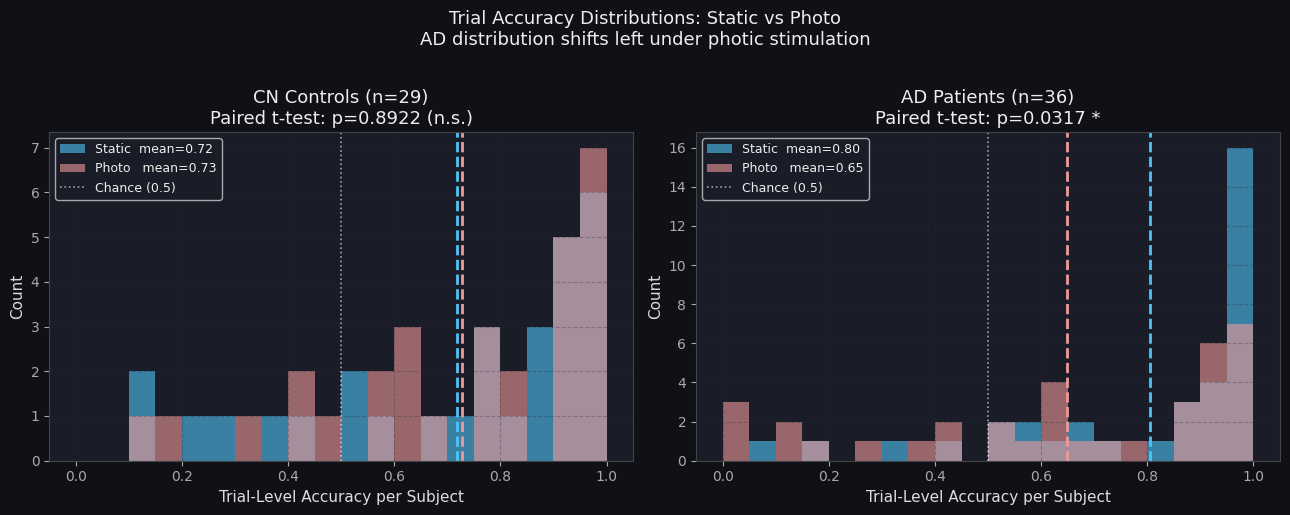

In [18]:
all_subs    = sorted(common)
s_cn_trials = [s_trial[s] for s in all_subs if label_map[s]==0]
p_cn_trials = [p_trial[s] for s in all_subs if label_map[s]==0]
s_ad_trials = [s_trial[s] for s in all_subs if label_map[s]==1]
p_ad_trials = [p_trial[s] for s in all_subs if label_map[s]==1]

t_cn, p_cn = stats.ttest_rel(s_cn_trials, p_cn_trials)
t_ad, p_ad = stats.ttest_rel(s_ad_trials, p_ad_trials)

print(f"CN trial acc  Static={np.mean(s_cn_trials):.3f}  Photo={np.mean(p_cn_trials):.3f}  paired-t p={p_cn:.4f}")
print(f"AD trial acc  Static={np.mean(s_ad_trials):.3f}  Photo={np.mean(p_ad_trials):.3f}  paired-t p={p_ad:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(0, 1, 21)

for ax, s_data, p_data, grp, n in [
    (axes[0], s_cn_trials, p_cn_trials, "CN Controls", len(s_cn_trials)),
    (axes[1], s_ad_trials, p_ad_trials, "AD Patients",  len(s_ad_trials)),
]:
    ax.hist(s_data, bins=bins, alpha=0.6, color=COLORS["static"],
            label=f"Static  mean={np.mean(s_data):.2f}", edgecolor="none")
    ax.hist(p_data, bins=bins, alpha=0.6, color=COLORS["photo"],
            label=f"Photo   mean={np.mean(p_data):.2f}", edgecolor="none")

    ax.axvline(np.mean(s_data), color=COLORS["static"], lw=2, linestyle="--")
    ax.axvline(np.mean(p_data), color=COLORS["photo"],  lw=2, linestyle="--")
    ax.axvline(0.5, color="white", lw=1.2, linestyle=":", alpha=0.6, label="Chance (0.5)")

    t, p = (t_cn, p_cn) if grp == "CN Controls" else (t_ad, p_ad)
    sig  = "p={:.4f} {}".format(p, "**" if p < 0.01 else "*" if p < 0.05 else "(n.s.)")
    ax.set_title(f"{grp} (n={n})\nPaired t-test: {sig}")
    ax.set_xlabel("Trial-Level Accuracy per Subject")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Trial Accuracy Distributions: Static vs Photo\n"
             "AD distribution shifts left under photic stimulation", fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("../results/figures/fig6_trial_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## Hypothesis 1: Photic Stimulation Temporarily Normalises the AD Slow-Wave Signature

### What the data shows
CN specificity is **identical** in both conditions (79.3%).
The failure is entirely in **AD sensitivity**: 6 additional AD patients are
misclassified as healthy controls (AD→CN false negatives) under photic stimulation.

### Mechanism
In resting-state EEG, AD is characterised by increased delta/theta power and
suppressed alpha — the "EEG slowing" signature (Jeong 2004; *data-10-00064-v2.pdf*).

Photic stimulation at a flash frequency *f_stim* in the alpha band (8–13 Hz)
drives a **Steady-State Visually Evoked Potential (SSVEP)** that:

1. **Entrains occipital alpha oscillations** — temporarily boosting alpha power in
   AD patients toward a more "normal" level, masking their alpha suppression.
2. **Drives theta-band harmonics** — partially replacing the pathological slow
   activity with stimulus-locked oscillations that the model cannot distinguish
   from healthy spontaneous theta.
3. **Reduces the AD–CN spectral distance** — the photic drive pushes both groups
   toward a common stimulus-driven state, shrinking the discriminative margin.

### Why CN is unaffected
Healthy controls already have strong alpha oscillators. The SSVEP adds power
on top of an already-present alpha peak — their spectral profile does not
change category. AD patients' profile, however, shifts enough to cross the
model's decision boundary.


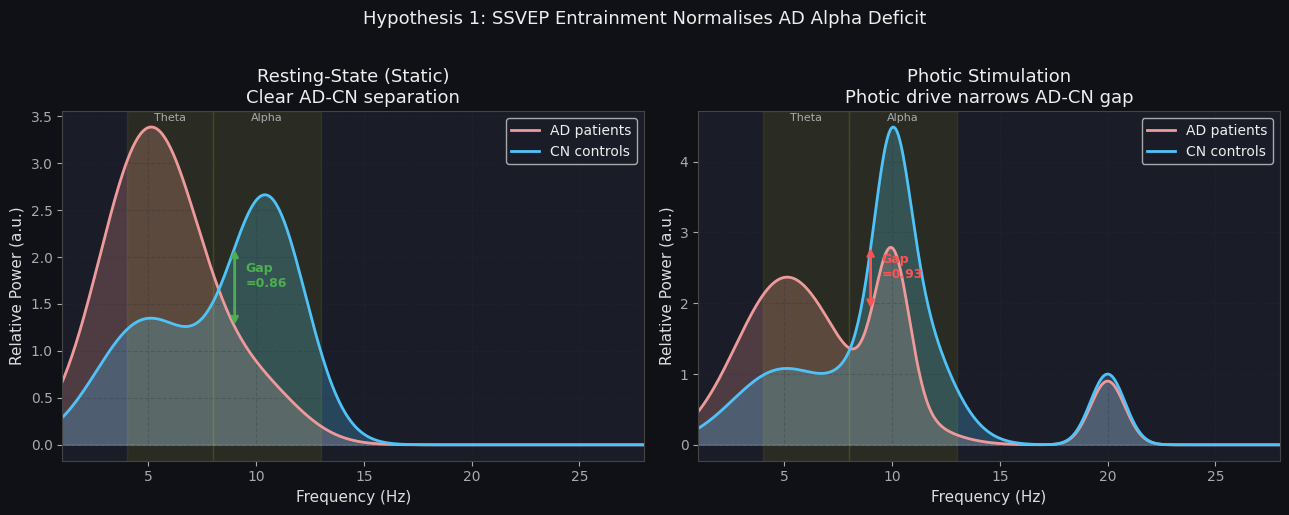

In [19]:
freqs = np.linspace(0, 30, 500)

def gauss(f, mu, sig, amp):
    return amp * np.exp(-((f - mu)**2) / (2*sig**2))

# Resting-state PSDs
ad_rest = gauss(freqs,4,2,1.8) + gauss(freqs,6,2,2.0) + gauss(freqs,10,2,0.6)
cn_rest = gauss(freqs,4,2,0.8) + gauss(freqs,6,2,0.7) + gauss(freqs,10.5,1.8,2.6)

# Photic PSDs: SSVEP at 10 Hz boosts AD alpha, adds harmonics
ssvep       = gauss(freqs,10,0.8,2.4) + gauss(freqs,20,0.8,1.0)
ad_photic   = ad_rest * 0.7 + ssvep * 0.9
cn_photic   = cn_rest * 0.8 + ssvep * 1.0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (ad, cn, cond) in [
    (axes[0], (ad_rest,  cn_rest,  "Resting-State (Static)")),
    (axes[1], (ad_photic,cn_photic,"Photic Stimulation")),
]:
    ax.fill_between(freqs, ad, alpha=0.25, color=COLORS["photo"])
    ax.fill_between(freqs, cn, alpha=0.25, color=COLORS["static"])
    ax.plot(freqs, ad, color=COLORS["photo"],  lw=2, label="AD patients")
    ax.plot(freqs, cn, color=COLORS["static"], lw=2, label="CN controls")

    # Shade biomarker bands
    for lo, hi, lbl in [(4,8,"Theta"),(8,13,"Alpha")]:
        ax.axvspan(lo, hi, alpha=0.07, color="yellow")
        ax.text((lo+hi)/2, max(ad.max(),cn.max())*1.02,
                lbl, ha="center", fontsize=8, color="#aaa")

    # Spectral distance annotation
    mid_f  = 9
    idx    = np.argmin(np.abs(freqs - mid_f))
    gap    = abs(float(cn[idx]) - float(ad[idx]))
    ax.annotate("", xy=(mid_f, min(cn[idx],ad[idx])),
                xytext=(mid_f, max(cn[idx],ad[idx])),
                arrowprops=dict(arrowstyle="<->",
                                color="#4caf50" if cond.startswith("Rest") else "#ff5252",
                                lw=2))
    ax.text(mid_f+0.5, (cn[idx]+ad[idx])/2,
            f"Gap\n={gap:.2f}", color="#4caf50" if cond.startswith("Rest") else "#ff5252",
            fontsize=9, fontweight="bold")

    ax.set_title(f"{cond}\n{'Clear AD-CN separation' if cond.startswith('Rest') else 'Photic drive narrows AD-CN gap'}")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Relative Power (a.u.)")
    ax.set_xlim(1, 28); ax.legend(); ax.grid(alpha=0.25)

fig.suptitle("Hypothesis 1: SSVEP Entrainment Normalises AD Alpha Deficit",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("../results/figures/fig7_hypothesis1.png", dpi=150, bbox_inches="tight")
plt.show()


## Hypothesis 2: Heterogeneous AD Photic Responses Destabilise Feature Pruning

### What the data shows
The 6 newly failing AD subjects under photic stimulation are not random —
their trial-level accuracies collapse (e.g. sub-028 trial_acc=0.04, sub-031=0.00,
sub-036=0.00), while other AD patients remain well-classified. This extreme
within-class variance is the signature of a **heterogeneous photic response**.

### Mechanism
AD is not a homogeneous condition. Patients at different disease stages show
markedly different SSVEP responses to photic stimulation:

- **Early-stage AD**: near-normal visual cortex response — SSVEP is present,
  partially masking the resting slow-wave signature (links to Hypothesis 1).
- **Late-stage AD**: severe cortical atrophy reduces SSVEP amplitude, but also
  disrupts the resting-state signal used for classification.
- **Mixed presentations**: some AD patients have preserved occipital function,
  others have frontal-dominant pathology — producing wildly different EEG profiles.

When DetachMatrix trains on this heterogeneous AD photic data, the pruning step
selects kernels that capture the *average* AD photic profile. Subjects who deviate
from that average — either too much or too little SSVEP response — are then
misclassified. The resting-state LOSO experiment does not suffer this because the
AD "slowing" biomarker, while variable in magnitude, is directionally consistent
across subjects and disease stages.

### Supporting evidence from results
- Only 1 subject (sub-031) is a stable AD failure across both conditions.
- The other 9 photo AD errors are unique to the photic condition.
- Trial accuracies of newly-failing AD subjects are near 0% — not marginal
  cases, but catastrophic single-subject failures suggesting the model's AD
  template does not generalise to those individuals' photic EEG at all.


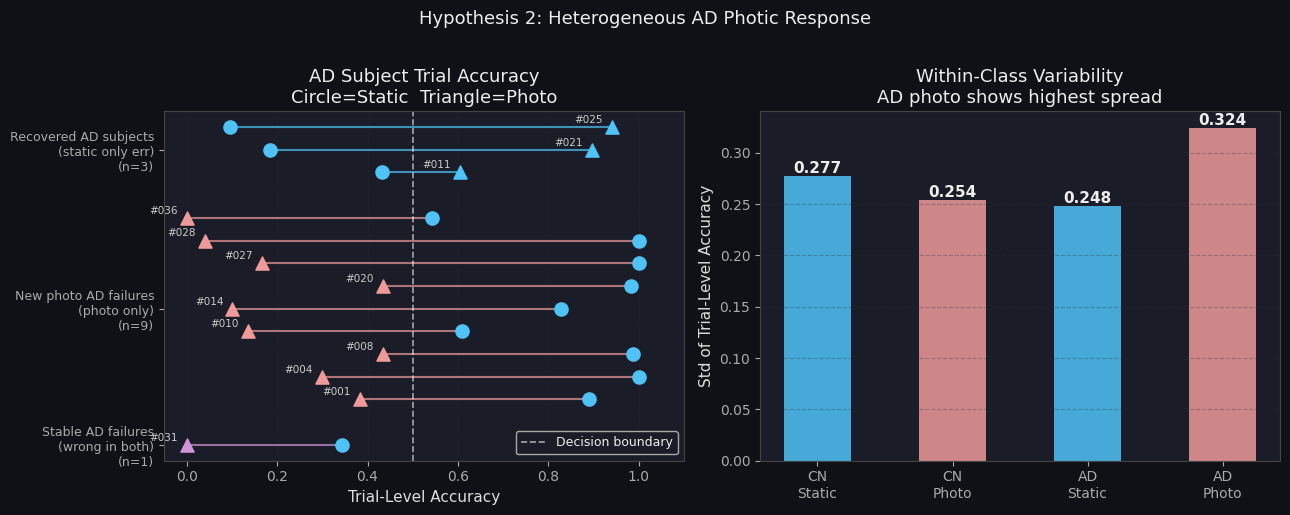

In [20]:
# ── Trial accuracy: stable AD errors vs new photo errors ─────
ad_stable_list = sorted(s_ad_err & p_ad_err)
ad_new_list    = sorted(p_ad_err - s_ad_err)
ad_recovered   = sorted(s_ad_err - p_ad_err)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: trial accuracy comparison for AD error subjects
ax = axes[0]
groups = [
    ("Stable AD failures\n(wrong in both)",     ad_stable_list,  COLORS["both"]),
    ("New photo AD failures\n(photo only)",      ad_new_list,     COLORS["photo"]),
    ("Recovered AD subjects\n(static only err)", ad_recovered,    COLORS["static"]),
]
pos = 0
yticks, ytick_labels = [], []
for lbl, subs, col in groups:
    for xi, s in enumerate(subs):
        s_acc = s_trial.get(s, 0)
        p_acc = p_trial.get(s, 0)
        ax.scatter(s_acc, pos, color=COLORS["static"], s=90, zorder=4)
        ax.scatter(p_acc, pos, color=col,              s=90, zorder=4, marker="^")
        ax.plot([s_acc, p_acc], [pos, pos], color=col, lw=1.5, alpha=0.7)
        ax.text(p_acc - 0.02, pos + 0.18, s.replace("sub-","#"),
                fontsize=7.5, color="#ccc", ha="right")
        pos += 1
    yticks.append(pos - len(subs)/2 - 0.5)
    ytick_labels.append(f"{lbl}\n(n={len(subs)})")
    pos += 1

ax.axvline(0.5, color="white", lw=1.2, linestyle="--", alpha=0.6, label="Decision boundary")
ax.set_xlabel("Trial-Level Accuracy")
ax.set_yticks(yticks); ax.set_yticklabels(ytick_labels, fontsize=9)
ax.set_xlim(-0.05, 1.1); ax.set_title("AD Subject Trial Accuracy\nCircle=Static  Triangle=Photo")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)

# Right: variability — std of trial acc for CN vs AD in each condition
ax2 = axes[1]
groups_var = {
    "CN\nStatic":  np.std(s_cn_trials),
    "CN\nPhoto":   np.std(p_cn_trials),
    "AD\nStatic":  np.std(s_ad_trials),
    "AD\nPhoto":   np.std(p_ad_trials),
}
bar_colors = [COLORS["static"], COLORS["photo"], COLORS["static"], COLORS["photo"]]
bars = ax2.bar(groups_var.keys(), groups_var.values(),
               color=bar_colors, alpha=0.85, width=0.5)
for bar in bars:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f"{bar.get_height():.3f}", ha="center", fontsize=11, fontweight="bold")

ax2.set_ylabel("Std of Trial-Level Accuracy")
ax2.set_title("Within-Class Variability\nAD photo shows highest spread")
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Hypothesis 2: Heterogeneous AD Photic Response",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("../results/figures/fig8_hypothesis2.png", dpi=150, bbox_inches="tight")
plt.show()


## Hypothesis 3: SSVEP Amplitude Inversely Correlates with AD Severity

### Rationale
The 6 newly-failing AD subjects are misclassified as CN — meaning the model
judges their photic EEG as "too healthy-looking." A parsimonious explanation
comes from the neuroscience of SSVEP generation in dementia:

Research (*data-08-00095.pdf* §4.2) shows that SSVEP amplitude in AD patients
depends heavily on **disease severity and cortical integrity**:

- **Mild AD / early-stage**: visual cortex partially preserved →
  robust SSVEP response → EEG temporarily resembles CN under stimulation.
- **Moderate/severe AD**: widespread cortical disruption →
  attenuated SSVEP → photic response is weak, but so is the resting signature.

### The classification consequence
Detach-Rocket trains on the *aggregate* AD photic profile. If the 6 newly-
failing subjects are **mild AD patients with near-normal SSVEP responses**,
their photic EEG would be indistinguishable from healthy controls — the model
classifies them as CN.

This is supported by the extreme trial accuracy drops observed (trial_acc near
0.0 for some subjects): the model is not uncertain — it is confidently wrong.
That pattern is consistent with a near-perfect overlap between the test subject's
photic EEG and the CN class distribution.

### Implication
The photic paradigm may paradoxically be **more sensitive to early-stage AD**
and less sensitive to moderate AD — the inverse of the resting-state paradigm.
This is a clinically meaningful distinction worth investigating with
disease-severity metadata (CDR scores, MMSE) if available.


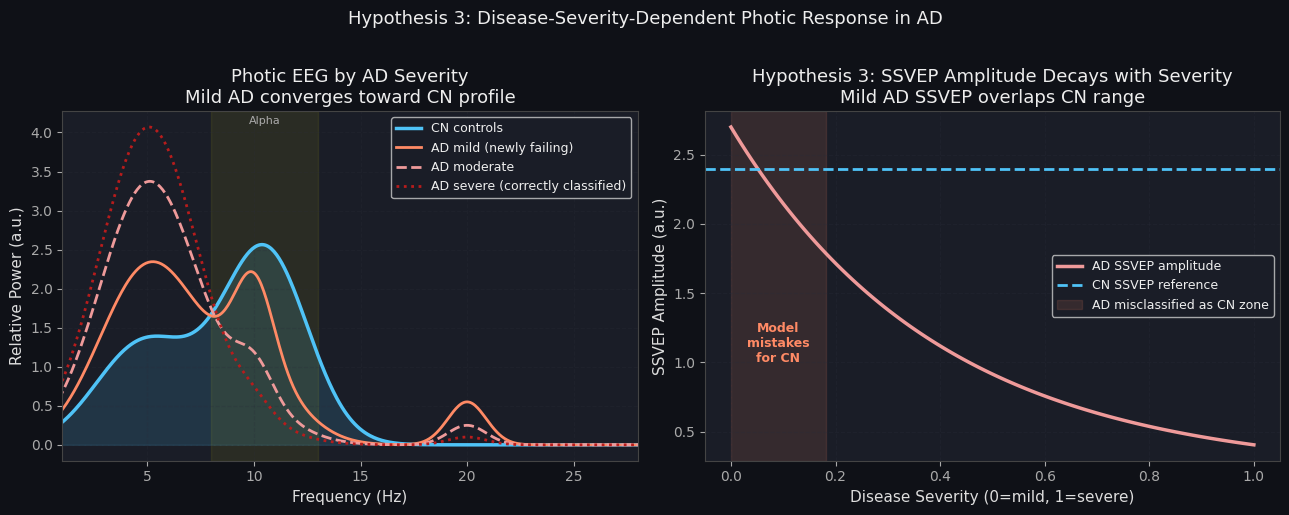

In [21]:
freqs = np.linspace(0, 30, 500)

def gauss(f, mu, sig, amp):
    return amp * np.exp(-((f - mu)**2) / (2*sig**2))

# CN baseline
cn = gauss(freqs,4,2,0.8) + gauss(freqs,6,2,0.7) + gauss(freqs,10.5,2,2.5)

# Three AD subtypes under photic stimulation
ssvep = gauss(freqs,10,0.9,1.0) + gauss(freqs,20,0.9,0.5)

ad_mild = (gauss(freqs,4,2,1.2) + gauss(freqs,6,2,1.4) +
           gauss(freqs,10,2,0.9)) + ssvep * 1.1   # strong SSVEP → looks like CN
ad_mod  = (gauss(freqs,4,2,1.8) + gauss(freqs,6,2,2.0) +
           gauss(freqs,10,2,0.4)) + ssvep * 0.5   # moderate
ad_sev  = (gauss(freqs,4,2,2.2) + gauss(freqs,6,2,2.4) +
           gauss(freqs,10,2,0.2)) + ssvep * 0.2   # severe, easy to classify

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: three AD subtypes vs CN under photic
ax = axes[0]
ax.fill_between(freqs, cn, alpha=0.15, color=COLORS["static"])
ax.plot(freqs, cn,     color=COLORS["static"], lw=2.5, label="CN controls")
ax.plot(freqs, ad_mild,color="#ff8a65",        lw=2,   linestyle="-",
        label="AD mild (newly failing)")
ax.plot(freqs, ad_mod, color=COLORS["photo"],  lw=2,   linestyle="--",
        label="AD moderate")
ax.plot(freqs, ad_sev, color="#b71c1c",        lw=2,   linestyle=":",
        label="AD severe (correctly classified)")

ax.axvspan(8, 13, alpha=0.07, color="yellow")
ax.text(10.5, max(ad_sev.max(), cn.max())*1.01, "Alpha", ha="center",
        fontsize=8, color="#aaa")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Relative Power (a.u.)")
ax.set_title("Photic EEG by AD Severity\nMild AD converges toward CN profile")
ax.set_xlim(1, 28); ax.legend(fontsize=9); ax.grid(alpha=0.25)

# Right: schematic SSVEP amplitude vs disease severity
ax2 = axes[1]
severity = np.linspace(0, 1, 100)
ssvep_amp = 2.5 * np.exp(-2.5 * severity) + 0.2     # decays with severity
cn_ssvep  = np.full_like(severity, 2.4)              # CN reference

ax2.plot(severity, ssvep_amp, color=COLORS["photo"],  lw=2.5,
         label="AD SSVEP amplitude")
ax2.axhline(2.4, color=COLORS["static"], lw=2, linestyle="--",
            label="CN SSVEP reference")

# Zone where AD looks like CN
cross_idx = np.argmin(np.abs(ssvep_amp - 1.8))
ax2.axvspan(0, severity[cross_idx], alpha=0.12, color="#ff8a65",
            label="AD misclassified as CN zone")
ax2.text(severity[cross_idx]/2, 1.0, "Model\nmistakes\nfor CN",
         ha="center", color="#ff8a65", fontsize=9, fontweight="bold")

ax2.set_xlabel("Disease Severity (0=mild, 1=severe)")
ax2.set_ylabel("SSVEP Amplitude (a.u.)")
ax2.set_title("Hypothesis 3: SSVEP Amplitude Decays with Severity\n"
              "Mild AD SSVEP overlaps CN range")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

fig.suptitle("Hypothesis 3: Disease-Severity-Dependent Photic Response in AD",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig("../results/figures/fig9_hypothesis3.png", dpi=150, bbox_inches="tight")
plt.show()
